# Drive mounting

In [1]:
# Connexion à Google Drive
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/P9/Src')

Mounted at /content/drive


# Importing packages

In [2]:
# 1. IMPORTS DE LA BIBLIOTHÈQUE STANDARD
import os
import glob
import json
import random
import zipfile

# 2. IMPORTS DES BIBLIOTHÈQUES TIERS (IMAGES & DATA)
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive  # (Spécifique à Google Colab)

# 3. DEEP LEARNING (TENSORFLOW & DEEPLABV3+ SPECIFIC)
import tensorflow as tf
from tensorflow.keras import backend as K
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    BatchNormalization,
    Activation,
    UpSampling2D,
    Concatenate,
    AveragePooling2D
)
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)


In [3]:
# Configuration de la mémoire du GPU pour éviter le crash CUDA
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ Memory Growth activée sur {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)


✅ Memory Growth activée sur 1 GPU(s)


# Chargement des données

In [5]:
isic_dir_drive = "/content/drive/MyDrive/P9/Src/Data/ISIC2018"
local_base_dir = "/content/P9/Data/ISIC2018"

zip_files = glob.glob(os.path.join(isic_dir_drive, "**/*.zip"), recursive=True)

if len(zip_files) == 0:
    print(f"❌ Aucun fichier ZIP trouvé dans {isic_dir_drive}")
else:
    print(f"📦 {len(zip_files)} fichiers ZIP trouvés. Décompression VERS LE SSD LOCAL DE COLAB...")

    for zip_path in zip_files:
        sub_folder = os.path.relpath(os.path.dirname(zip_path), isic_dir_drive)
        local_extract_dir = os.path.join(local_base_dir, sub_folder)
        os.makedirs(local_extract_dir, exist_ok=True)

        print(f"Extraction de {os.path.basename(zip_path)} dans {local_extract_dir}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(local_extract_dir)

    print(f"✅ Terminé ! Vos dossiers (test, train, validation) ont été recréés localement dans {local_base_dir}")


📦 6 fichiers ZIP trouvés. Décompression VERS LE SSD LOCAL DE COLAB...
Extraction de Test_GroundTruth.zip dans /content/P9/Data/ISIC2018/test...
Extraction de Test_Input.zip dans /content/P9/Data/ISIC2018/test...
Extraction de Training_GroundTruth.zip dans /content/P9/Data/ISIC2018/train...
Extraction de Training_Input.zip dans /content/P9/Data/ISIC2018/train...
Extraction de Validation_GroundTruth.zip dans /content/P9/Data/ISIC2018/validation...
Extraction de Validation_Input.zip dans /content/P9/Data/ISIC2018/validation...
✅ Terminé ! Vos dossiers (test, train, validation) ont été recréés localement dans /content/P9/Data/ISIC2018


# Definition des paths

In [6]:
train_images_dir = '/content/P9/Data/ISIC2018/train/Training_Input'
train_masks_dir = '/content/P9/Data/ISIC2018/train/Training_GroundTruth'

validation_images_dir = '/content/P9/Data/ISIC2018/validation/Validation_Input'
validation_masks_dir = '/content/P9/Data/ISIC2018/validation/Validation_GroundTruth'

test_images_dir = '/content/P9/Data/ISIC2018/test/Test_Input'
test_masks_dir = '/content/P9/Data/ISIC2018/test/Test_GroundTruth'

In [7]:
train_images_paths = sorted(glob.glob(os.path.join(train_images_dir, '*.jpg')))
train_masks_paths = sorted(glob.glob(os.path.join(train_masks_dir, '*.png')))
print(f"Nombre d'images d'entraînement : {len(train_images_paths)}")
print(f"Nombre de masques d'entraînement : {len(train_masks_paths)}")

validation_images_paths = sorted(glob.glob(os.path.join(validation_images_dir, '*.jpg')))
validation_masks_paths = sorted(glob.glob(os.path.join(validation_masks_dir, '*.png')))
print(f"Nombre d'images de validation : {len(validation_images_paths)}")
print(f"Nombre de masques de validation : {len(validation_masks_paths)}")

test_images_paths = sorted(glob.glob(os.path.join(test_images_dir, '*.jpg')))
test_masks_paths = sorted(glob.glob(os.path.join(test_masks_dir, '*.png')))
print(f"Nombre d'images de test : {len(test_images_paths)}")
print(f"Nombre de masques de test : {len(test_masks_paths)}")


Nombre d'images d'entraînement : 2594
Nombre de masques d'entraînement : 2594
Nombre d'images de validation : 100
Nombre de masques de validation : 100
Nombre d'images de test : 1000
Nombre de masques de test : 1000


# Data loaders

In [ ]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
BATCH_SIZE = 32

class ISIC2018Generator(tf.keras.utils.Sequence):
    def __init__(self, img_paths, mask_paths, batch_size=BATCH_SIZE, img_size=(IMG_HEIGHT, IMG_WIDTH)):
        self.img_paths = list(img_paths)
        self.mask_paths = list(mask_paths)
        self.batch_size = batch_size
        self.img_size = img_size

    def __len__(self):
        # Nombre de batchs par époque
        return int(np.ceil(len(self.img_paths) / self.batch_size))

    def __getitem__(self, idx):
        # Récupération des chemins pour le lot (batch) actuel
        batch_img_paths = self.img_paths[idx * self.batch_size : (idx + 1) * self.batch_size]
        batch_mask_paths = self.mask_paths[idx * self.batch_size : (idx + 1) * self.batch_size]
        
        # Initialisation des tenseurs contenant les images et masques du batch
        x = np.zeros((len(batch_img_paths), self.img_size[0], self.img_size[1], 3), dtype="float32")
        y = np.zeros((len(batch_img_paths), self.img_size[0], self.img_size[1], 1), dtype="float32")
        
        for j, (img_path, mask_path) in enumerate(zip(batch_img_paths, batch_mask_paths)):
            # 1. Lecture et redimensionnement de l'image
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (self.img_size[1], self.img_size[0]))
            
            # 2. Lecture et redimensionnement du masque
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, (self.img_size[1], self.img_size[0]), interpolation=cv2.INTER_NEAREST)
            
            # 3. Normalisation (entre 0 et 1)
            img = img / 255.0
            mask = mask / 255.0
            
            # 4. Binarisation stricte du masque
            mask = np.where(mask > 0.5, 1.0, 0.0) 
            
            # 5. Stockage dans le batch
            x[j] = img
            y[j] = np.expand_dims(mask, -1)
            
        return x, y

    def on_epoch_end(self):
        # Mélanger les données à la fin de chaque époque pour la robustesse de l'entraînement
        combined = list(zip(self.img_paths, self.mask_paths))
        random.shuffle(combined)
        shuffled = list(zip(*combined))
        if shuffled:
            self.img_paths, self.mask_paths = list(shuffled[0]), list(shuffled[1])

train_dataset = ISIC2018Generator(train_images_paths, train_masks_paths, batch_size=BATCH_SIZE)
val_dataset = ISIC2018Generator(validation_images_paths, validation_masks_paths, batch_size=BATCH_SIZE)
test_dataset = ISIC2018Generator(test_images_paths, test_masks_paths, batch_size=BATCH_SIZE)

print(f"✅ DataGenerators (sans Data Augmentation) prêts ! Batch size : {BATCH_SIZE}")


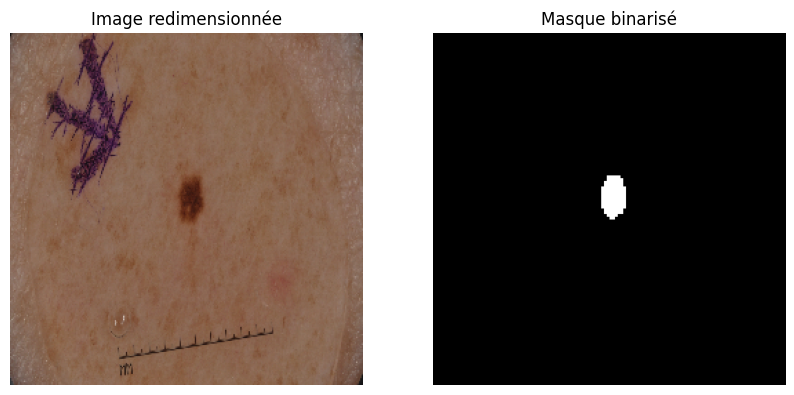

In [10]:
# Prendre un seul batch
for images, masks in train_dataset.take(1):
    plt.figure(figsize=(10, 5))
    
    plt.subplot(1, 2, 1)
    plt.title("Image redimensionnée")
    plt.imshow(images[0])
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.title("Masque binarisé")
    plt.imshow(tf.squeeze(masks[0]), cmap='gray') # squeeze enlève la dimension vide du canal
    plt.axis('off')
    
    plt.show()
    break


# DeepLabV3+ model

In [11]:
# 1. Fonction utilitaire pour créer des blocs convolutionnels
def convolution_block(block_input, num_filters=256, kernel_size=3, dilation_rate=1, use_bias=False):
    x = Conv2D(
        num_filters,
        kernel_size=kernel_size,
        dilation_rate=dilation_rate,
        padding="same",
        use_bias=use_bias,
        kernel_initializer=tf.keras.initializers.HeNormal()
    )(block_input)
    x = BatchNormalization()(x)
    return Activation('relu')(x)

# 2. Le cœur de DeepLabV3+ : Atrous Spatial Pyramid Pooling (ASPP)
def DilatedSpatialPyramidPooling(dspp_input):
    dims = dspp_input.shape
    
    # Pooling global
    x = AveragePooling2D(pool_size=(dims[-3], dims[-2]))(dspp_input)
    x = convolution_block(x, kernel_size=1, use_bias=True)
    out_pool = UpSampling2D(
        size=(dims[-3] // x.shape[1], dims[-2] // x.shape[2]), interpolation="bilinear",
    )(x)

    # Convolutions dilatées à différents taux
    out_1 = convolution_block(dspp_input, kernel_size=1, dilation_rate=1)
    out_6 = convolution_block(dspp_input, kernel_size=3, dilation_rate=6)
    out_12 = convolution_block(dspp_input, kernel_size=3, dilation_rate=12)
    out_18 = convolution_block(dspp_input, kernel_size=3, dilation_rate=18)

    # Concaténation de toutes les échelles
    x = Concatenate(axis=-1)([out_pool, out_1, out_6, out_12, out_18])
    output = convolution_block(x, kernel_size=1)
    return output

# 3. Construction finale du modèle DeepLabV3+
def DeeplabV3Plus(image_size, num_classes=1):
    model_input = Input(shape=(image_size, image_size, 3))
    
    # ENCODEUR : On utilise un ResNet50 pré-entraîné
    resnet50 = tf.keras.applications.ResNet50(
        weights="imagenet", include_top=False, input_tensor=model_input
    )
    
    # Récupérer les features "Profondes" pour le module ASPP
    x = resnet50.get_layer("conv4_block6_2_relu").output
    x = DilatedSpatialPyramidPooling(x)

    # Récupérer les features "Basses" (détails fins) pour le décodeur
    input_a = UpSampling2D(
        size=(image_size // 4 // x.shape[1], image_size // 4 // x.shape[2]),
        interpolation="bilinear",
    )(x)
    input_b = resnet50.get_layer("conv2_block3_2_relu").output
    input_b = convolution_block(input_b, num_filters=48, kernel_size=1)

    # DÉCODEUR : Fusion et reconstruction de l'image
    x = Concatenate(axis=-1)([input_a, input_b])
    x = convolution_block(x)
    x = convolution_block(x)
    
    # Remise à l'échelle (256x256)
    x = UpSampling2D(
        size=(image_size // x.shape[1], image_size // x.shape[2]),
        interpolation="bilinear",
    )(x)
    
    # COUCHE DE SORTIE (Segmentation binaire)
    model_output = Conv2D(num_classes, kernel_size=(1, 1), activation="sigmoid", padding="same")(x)
    
    return tf.keras.Model(inputs=model_input, outputs=model_output)

# Instanciation du modèle DeepLabV3+
deeplabv3plus_model = DeeplabV3Plus(image_size=IMG_HEIGHT, num_classes=1)
deeplabv3plus_model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 11,852,353 (45.21 MB)

 Trainable params: 11,819,617 (45.09 MB)

 Non-trainable params: 32,736 (127.88 KB)

# Metriques

In [12]:
# 1. Le coefficient Dice (Métrique de similarité)
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

# 2. La Dice Loss (Ce que le modèle va essayer de minimiser)
def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

# 3. L'IoU (Intersection over Union)
def iou(y_true, y_pred, smooth=1e-6):
    intersection = K.sum(K.abs(y_true * y_pred), axis=[1,2,3])
    union = K.sum(y_true,[1,2,3]) + K.sum(y_pred,[1,2,3]) - intersection
    iou = K.mean((intersection + smooth) / (union + smooth), axis=0)
    return iou


In [13]:
deeplabv3plus_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss=dice_loss, 
    metrics=[dice_coef, iou, 'accuracy']
)

# Callbacks et entrainement

In [14]:
# 1. Définir le chemin de sauvegarde sur votre Drive
checkpoint_filepath = '/content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5'

# 2. Configurer les "règles" de l'entraînement
callbacks = [
    # Sauvegarde le modèle uniquement si la perte de validation (val_loss) s'améliore
    ModelCheckpoint(checkpoint_filepath, monitor='val_loss', save_best_only=True, mode='min', verbose=1),
    
    # Arrête l'entraînement si le modèle stagne pendant 10 epochs (Patience)
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    
    # Divise le Learning Rate par 2 si la perte ne descend plus (Patience 5)
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

# 3. Lancer l'entraînement

print("Début de l'entraînement de DeepLabV3+...")
history = deeplabv3plus_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=100,
    callbacks=callbacks
)

Début de l'entraînement de DeepLabV3+...
Epoch 1/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 767ms/step - accuracy: 0.9030 - dice_coef: 0.7143 - iou: 0.5169 - loss: 0.2857
Epoch 1: val_loss improved from None to 0.61260, saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5



Epoch 1: finished saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 155s 923ms/step - accuracy: 0.9319 - dice_coef: 0.8163 - iou: 0.6420 - loss: 0.1846 - val_accuracy: 0.7843 - val_dice_coef: 0.3851 - val_iou: 0.2346 - val_loss: 0.6126 - learning_rate: 1.0000e-04
Epoch 2/100
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.9588 - dice_coef: 0.8951 - iou: 0.7654 - loss: 0.1049
Epoch 2: val_loss did not improve from 0.61260
82/82 ━━━━━━━━━━━━━━━━━━━━ 39s 470ms/step - accuracy: 0.9592 - dice_coef: 0.8965 - iou: 0.7673 - loss: 0.1043 - val_accuracy: 0.7324 - val_dice_coef: 0.1269 - val_iou: 0.0856 - val_loss: 0.8760 - learning_rate: 1.0000e-04
Epoch 3/100
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 459ms/step - accuracy: 0.9645 - dice_coef: 0.9105 - iou: 0.7946 - loss: 0.0895
Epoch 3: val_loss did not improve from 0.61260
82/82 ━━━━━━━━━━━━━━━━━━━━ 39s 467ms/step - accuracy: 0.9654 - dice_coef: 0.9056 - iou: 0.7897 - loss: 0.0886 - val_acc


Epoch 9: finished saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 515ms/step - accuracy: 0.9827 - dice_coef: 0.9558 - iou: 0.8808 - loss: 0.0437 - val_accuracy: 0.8143 - val_dice_coef: 0.5471 - val_iou: 0.4886 - val_loss: 0.5119 - learning_rate: 5.0000e-05
Epoch 10/100
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9835 - dice_coef: 0.9581 - iou: 0.8873 - loss: 0.0419
Epoch 10: val_loss improved from 0.51189 to 0.22367, saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5



Epoch 10: finished saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 521ms/step - accuracy: 0.9839 - dice_coef: 0.9587 - iou: 0.8863 - loss: 0.0413 - val_accuracy: 0.8955 - val_dice_coef: 0.7934 - val_iou: 0.6856 - val_loss: 0.2237 - learning_rate: 5.0000e-05
Epoch 11/100
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.9846 - dice_coef: 0.9622 - iou: 0.8941 - loss: 0.0378
Epoch 11: val_loss improved from 0.22367 to 0.15789, saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5



Epoch 11: finished saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 44s 522ms/step - accuracy: 0.9851 - dice_coef: 0.9603 - iou: 0.8923 - loss: 0.0378 - val_accuracy: 0.9219 - val_dice_coef: 0.8523 - val_iou: 0.7608 - val_loss: 0.1579 - learning_rate: 5.0000e-05
Epoch 12/100
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9850 - dice_coef: 0.9615 - iou: 0.8909 - loss: 0.0385
Epoch 12: val_loss improved from 0.15789 to 0.13572, saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5


...


Epoch 17: finished saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 516ms/step - accuracy: 0.9869 - dice_coef: 0.9662 - iou: 0.9057 - loss: 0.0333 - val_accuracy: 0.9381 - val_dice_coef: 0.8917 - val_iou: 0.8003 - val_loss: 0.1141 - learning_rate: 5.0000e-05
Epoch 18/100
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 467ms/step - accuracy: 0.9878 - dice_coef: 0.9686 - iou: 0.9125 - loss: 0.0314
Epoch 18: val_loss improved from 0.11408 to 0.11187, saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5



Epoch 18: finished saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 518ms/step - accuracy: 0.9876 - dice_coef: 0.9684 - iou: 0.9110 - loss: 0.0315 - val_accuracy: 0.9402 - val_dice_coef: 0.8943 - val_iou: 0.8031 - val_loss: 0.1119 - learning_rate: 5.0000e-05
Epoch 19/100
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9890 - dice_coef: 0.9710 - iou: 0.9164 - loss: 0.0290
Epoch 19: val_loss did not improve from 0.11187
82/82 ━━━━━━━━━━━━━━━━━━━━ 40s 477ms/step - accuracy: 0.9889 - dice_coef: 0.9716 - iou: 0.9175 - loss: 0.0282 - val_accuracy: 0.9375 - val_dice_coef: 0.8896 - val_iou: 0.7937 - val_loss: 0.1150 - learning_rate: 5.0000e-05
Epoch 20/100
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.9882 - dice_coef: 0.9719 - iou: 0.9178 - loss: 0.0281
Epoch 20: val_loss improved from 0.11187 to 0.10981, saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5



Epoch 20: finished saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 513ms/step - accuracy: 0.9890 - dice_coef: 0.9707 - iou: 0.9165 - loss: 0.0280 - val_accuracy: 0.9421 - val_dice_coef: 0.8976 - val_iou: 0.8175 - val_loss: 0.1098 - learning_rate: 5.0000e-05
Epoch 21/100
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 466ms/step - accuracy: 0.9880 - dice_coef: 0.9687 - iou: 0.9078 - loss: 0.0313
Epoch 21: val_loss improved from 0.10981 to 0.10599, saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5



Epoch 21: finished saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 515ms/step - accuracy: 0.9883 - dice_coef: 0.9690 - iou: 0.9114 - loss: 0.0297 - val_accuracy: 0.9426 - val_dice_coef: 0.8979 - val_iou: 0.8126 - val_loss: 0.1060 - learning_rate: 5.0000e-05
Epoch 22/100
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step - accuracy: 0.9881 - dice_coef: 0.9695 - iou: 0.9156 - loss: 0.0305
Epoch 22: val_loss did not improve from 0.10599
82/82 ━━━━━━━━━━━━━━━━━━━━ 40s 477ms/step - accuracy: 0.9887 - dice_coef: 0.9694 - iou: 0.9150 - loss: 0.0285 - val_accuracy: 0.9407 - val_dice_coef: 0.8951 - val_iou: 0.8084 - val_loss: 0.1122 - learning_rate: 5.0000e-05
Epoch 23/100
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.9895 - dice_coef: 0.9736 - iou: 0.9218 - loss: 0.0264
Epoch 23: val_loss did not improve from 0.10599
82/82 ━━━━━━━━━━━━━━━━━━━━ 40s 474ms/step - accuracy: 0.9898 - dice_coef: 0.9739 - iou: 0.9233 - loss: 0.0260 - val


Epoch 30: finished saving model to /content/drive/MyDrive/P9/Src/models/best_deeplabv3+_isic2018.h5
82/82 ━━━━━━━━━━━━━━━━━━━━ 43s 511ms/step - accuracy: 0.9914 - dice_coef: 0.9773 - iou: 0.9329 - loss: 0.0220 - val_accuracy: 0.9428 - val_dice_coef: 0.9022 - val_iou: 0.8167 - val_loss: 0.1056 - learning_rate: 2.5000e-05
Epoch 31/100
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 465ms/step - accuracy: 0.9914 - dice_coef: 0.9779 - iou: 0.9330 - loss: 0.0221
Epoch 31: val_loss did not improve from 0.10560
82/82 ━━━━━━━━━━━━━━━━━━━━ 40s 474ms/step - accuracy: 0.9915 - dice_coef: 0.9760 - iou: 0.9305 - loss: 0.0219 - val_accuracy: 0.9362 - val_dice_coef: 0.8907 - val_iou: 0.7873 - val_loss: 0.1149 - learning_rate: 2.5000e-05
Epoch 32/100
81/82 ━━━━━━━━━━━━━━━━━━━━ 0s 464ms/step - accuracy: 0.9904 - dice_coef: 0.9754 - iou: 0.9263 - loss: 0.0246
Epoch 32: val_loss did not improve from 0.10560
82/82 ━━━━━━━━━━━━━━━━━━━━ 39s 473ms/step - accuracy: 0.9906 - dice_coef: 0.9757 - iou: 0.9283 - loss: 0.0243 - val

Courbes d'apprentissage

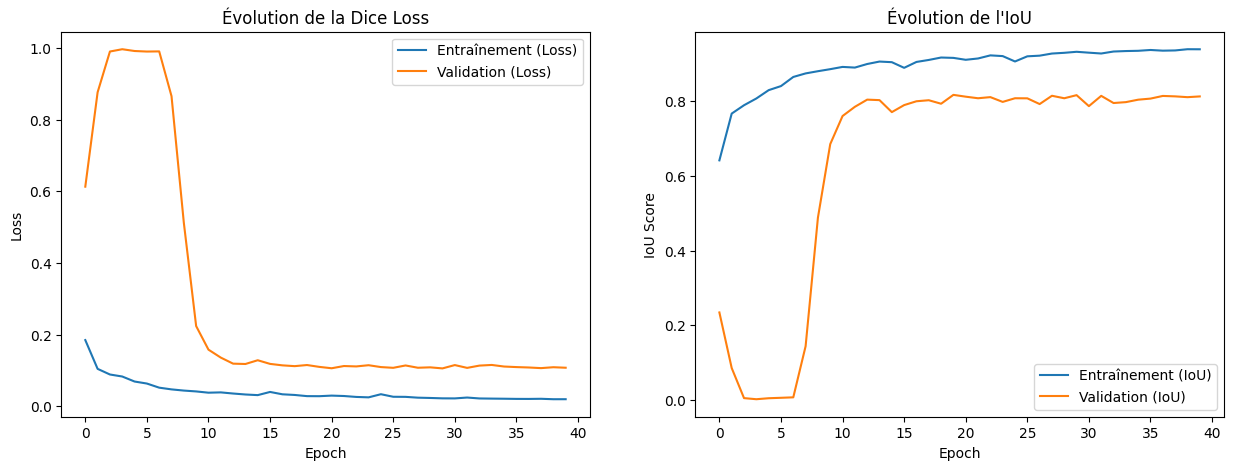

In [15]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    # Courbe de la fonction de perte (Loss)
    ax1.plot(history.history['loss'], label='Entraînement (Loss)')
    ax1.plot(history.history['val_loss'], label='Validation (Loss)')
    ax1.set_title('Évolution de la Dice Loss')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    
    # Courbe de l'IoU (Intersection over Union)
    ax2.plot(history.history['iou'], label='Entraînement (IoU)')
    ax2.plot(history.history['val_iou'], label='Validation (IoU)')
    ax2.set_title('Évolution de l\'IoU')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('IoU Score')
    ax2.legend()
    
    plt.show()

# Afficher les graphiques
plot_training_history(history)


# Visualisation des prédictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step


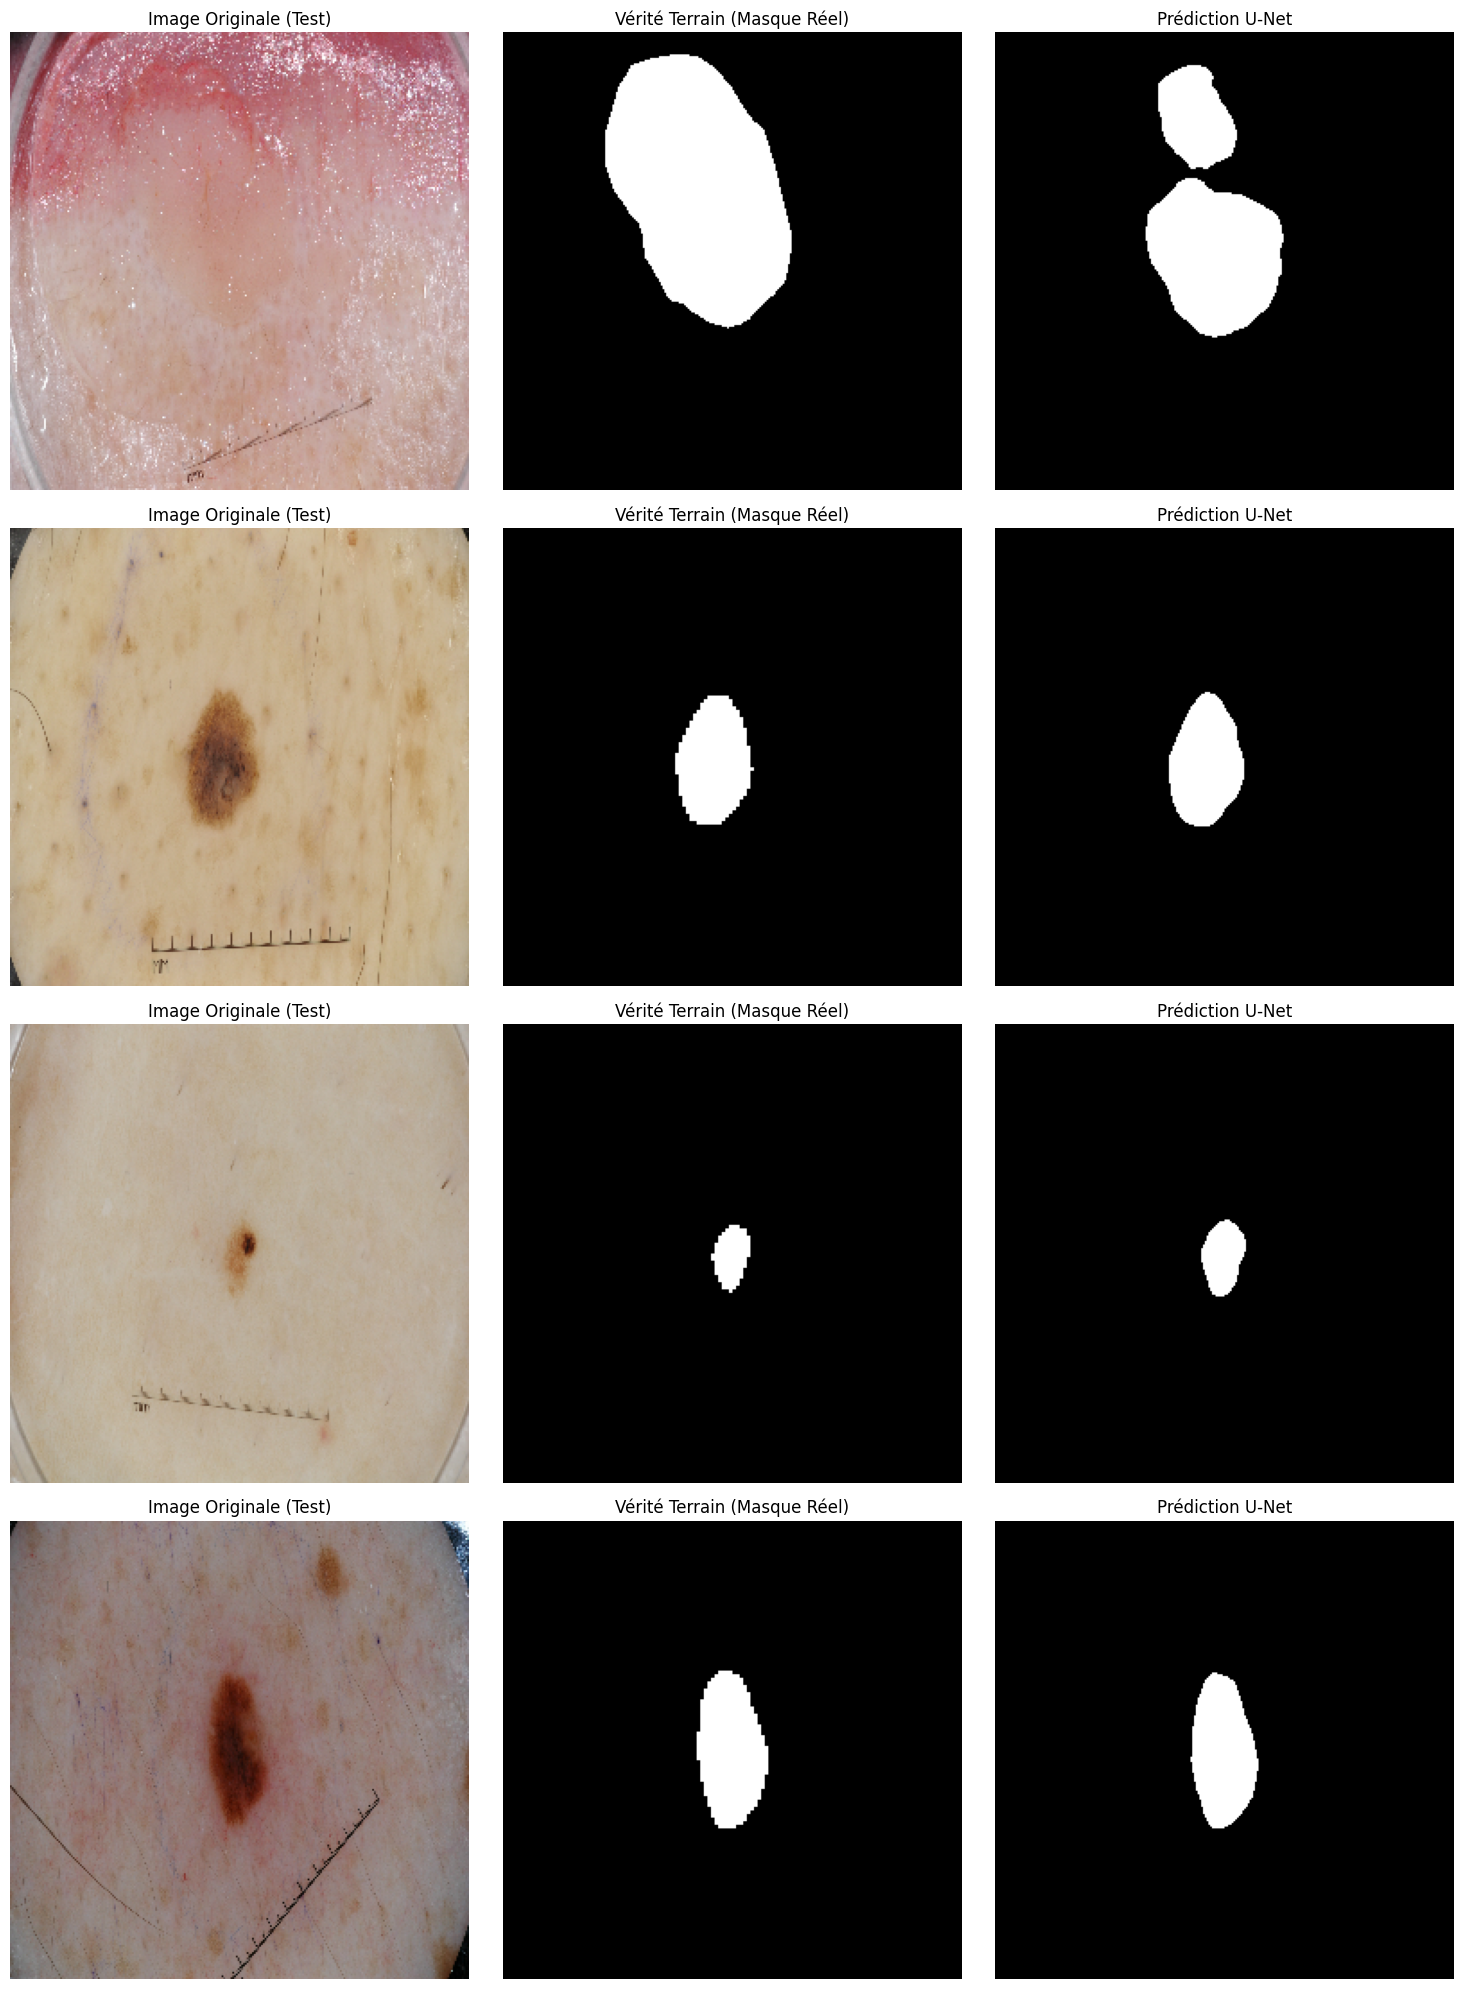

In [17]:
def visualize_predictions(dataset, model, num_samples=3):
    # On prend 1 seul batch du dataset de TEST
    for images, masks in dataset.take(1): 
        # Le modèle génère ses prédictions
        predictions = model.predict(images)
        
        # Binarisation : Si la probabilité > 50%, c'est une lésion (1), sinon peau saine (0)
        preds_bin = (predictions > 0.5).astype(np.float32)
        
        plt.figure(figsize=(15, 5 * num_samples))
        
        for i in range(num_samples):
            # 1. Image Originale
            plt.subplot(num_samples, 3, i*3 + 1)
            plt.title("Image Originale (Test)")
            plt.imshow(images[i])
            plt.axis('off')
            
            # 2. Vérité Terrain (Ground Truth)
            plt.subplot(num_samples, 3, i*3 + 2)
            plt.title("Vérité Terrain (Masque Réel)")
            plt.imshow(tf.squeeze(masks[i]), cmap='gray')
            plt.axis('off')
            
            # 3. Prédiction du Modèle U-Net
            plt.subplot(num_samples, 3, i*3 + 3)
            plt.title("Prédiction U-Net")
            plt.imshow(tf.squeeze(preds_bin[i]), cmap='gray')
            plt.axis('off')
            
        plt.tight_layout()
        plt.show()
        break # On s'arrête après un batch

# Lancer la visualisation sur les images de Test que le modèle n'a jamais vues !
visualize_predictions(test_dataset, deeplabv3plus_model, num_samples=4)


# Traçabilité des metriques et test

✅ Historique d'entraînement sauvegardé dans : /content/drive/MyDrive/P9/Src/Experiences/DeepLabV3plus/DeepLabV3plus_training_history.csv

Évaluation sur l'ensemble de Test...
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 268ms/step - accuracy: 0.9294 - dice_coef: 0.8723 - iou: 0.7834 - loss: 0.1284
loss: 0.1284
compile_metrics: 0.8723
✅ Scores de test sauvegardés dans : /content/drive/MyDrive/P9/Src/Experiences/DeepLabV3plus/DeepLabV3plus_test_scores.txt
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step
✅ Image de prédictions sauvegardée dans : /content/drive/MyDrive/P9/Src/Experiences/DeepLabV3plus/DeepLabV3plus_test_predictions.png


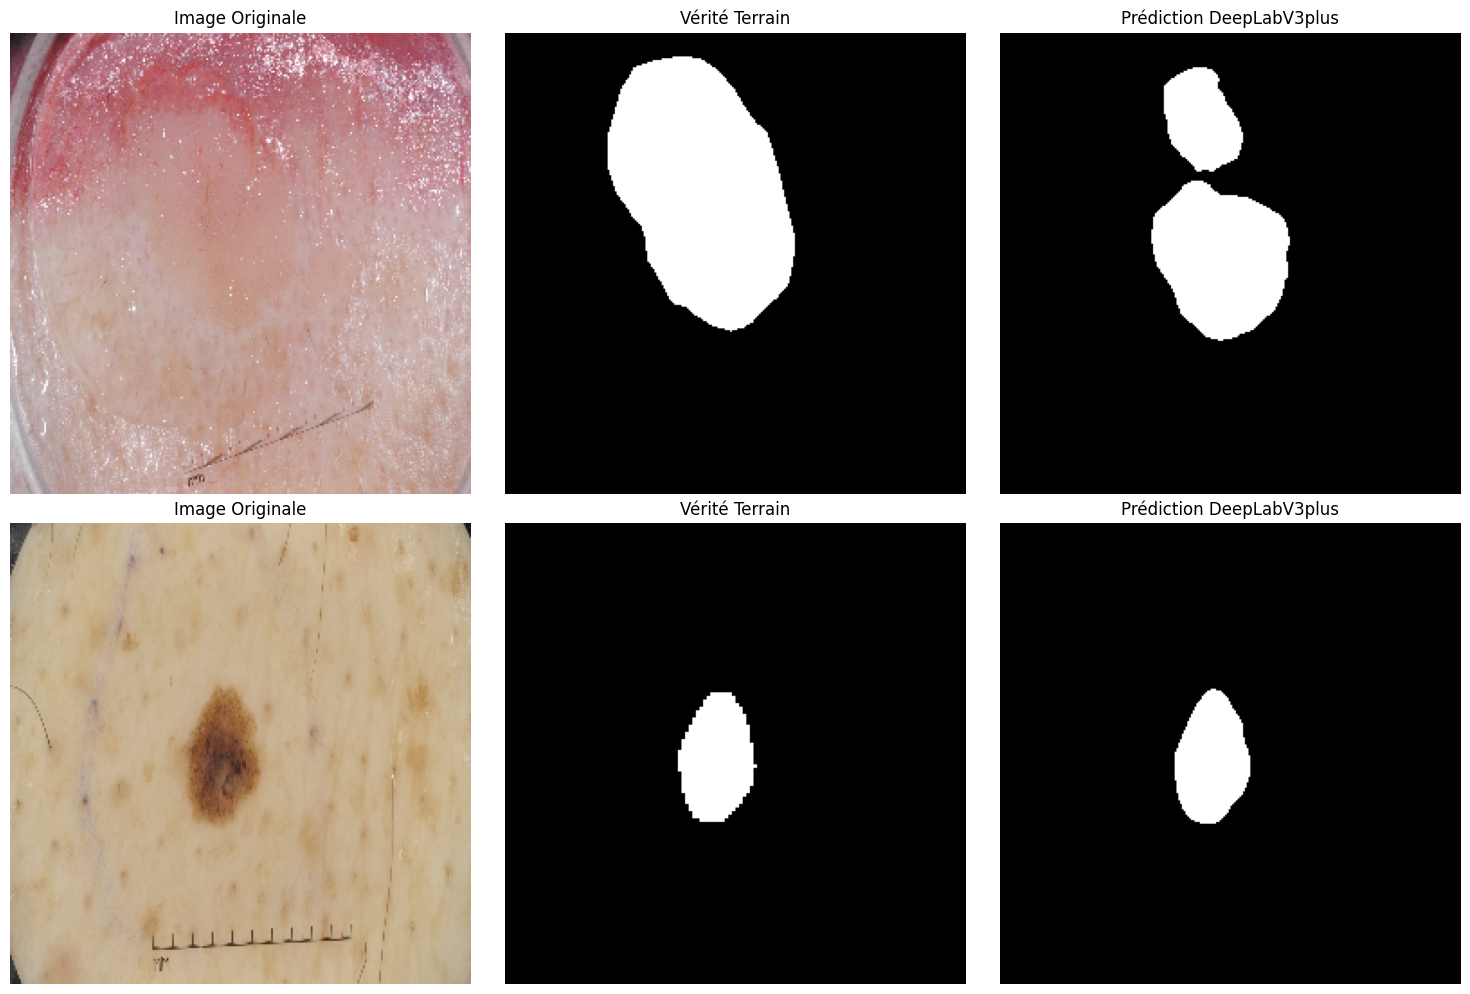

In [21]:
# Création du dossier d'expérience s'il n'existe pas
exp_dir = '/content/drive/MyDrive/P9/Src/Experiences/DeepLabV3plus'
os.makedirs(exp_dir, exist_ok=True)

# 1. SAUVEGARDE DE L'HISTORIQUE D'ENTRAÎNEMENT (Loss, IoU, Dice)
history_df = pd.DataFrame(history.history)
history_csv_path = os.path.join(exp_dir, 'DeepLabV3plus_training_history.csv')
history_df.to_csv(history_csv_path, index=False)
print(f"✅ Historique d'entraînement sauvegardé dans : {history_csv_path}")


# 2. ÉVALUATION ET SAUVEGARDE DES SCORES SUR LE SET DE TEST
print("\nÉvaluation sur l'ensemble de Test...")
# On charge les meilleurs poids sauvegardés par le callback au cas où
deeplabv3plus_model.load_weights(checkpoint_filepath) 

# Le modèle calcule la loss, l'IoU, le Dice et l'Accuracy sur le dataset de test
test_results = deeplabv3plus_model.evaluate(test_dataset, verbose=1)

# Les noms des métriques correspondent à l'ordre défini lors de la compilation
metrics_names = deeplabv3plus_model.metrics_names 

# Sauvegarde dans un fichier texte
test_scores_path = os.path.join(exp_dir, 'DeepLabV3plus_test_scores.txt')
with open(test_scores_path, 'w') as f:
    f.write("=== RÉSULTATS DE DeepLabV3plus SUR ISIC 2018 (TEST SET) ===\n")
    for name, score in zip(metrics_names, test_results):
        f.write(f"{name}: {score:.4f}\n")
        print(f"{name}: {score:.4f}")
        
print(f"✅ Scores de test sauvegardés dans : {test_scores_path}")


# 3. SAUVEGARDE DES PRÉDICTIONS VISUELLES
# On réutilise la logique de visualisation mais on l'enregistre
for images, masks in test_dataset.take(1): 
    predictions = deeplabv3plus_model.predict(images)
    preds_bin = (predictions > 0.5).astype(np.float32)
    
    plt.figure(figsize=(15, 10))
    for i in range(2): # On sauvegarde 2 exemples
        # Image Originale
        plt.subplot(2, 3, i*3 + 1)
        plt.title("Image Originale")
        plt.imshow(images[i])
        plt.axis('off')
        
        # Vérité Terrain
        plt.subplot(2, 3, i*3 + 2)
        plt.title("Vérité Terrain")
        plt.imshow(tf.squeeze(masks[i]), cmap='gray')
        plt.axis('off')
        
        # Prédiction U-Net
        plt.subplot(2, 3, i*3 + 3)
        plt.title("Prédiction DeepLabV3plus")
        plt.imshow(tf.squeeze(preds_bin[i]), cmap='gray')
        plt.axis('off')
    
    plt.tight_layout()
    predictions_img_path = os.path.join(exp_dir, 'DeepLabV3plus_test_predictions.png')
    plt.savefig(predictions_img_path)
    print(f"✅ Image de prédictions sauvegardée dans : {predictions_img_path}")
    plt.show()
    break

